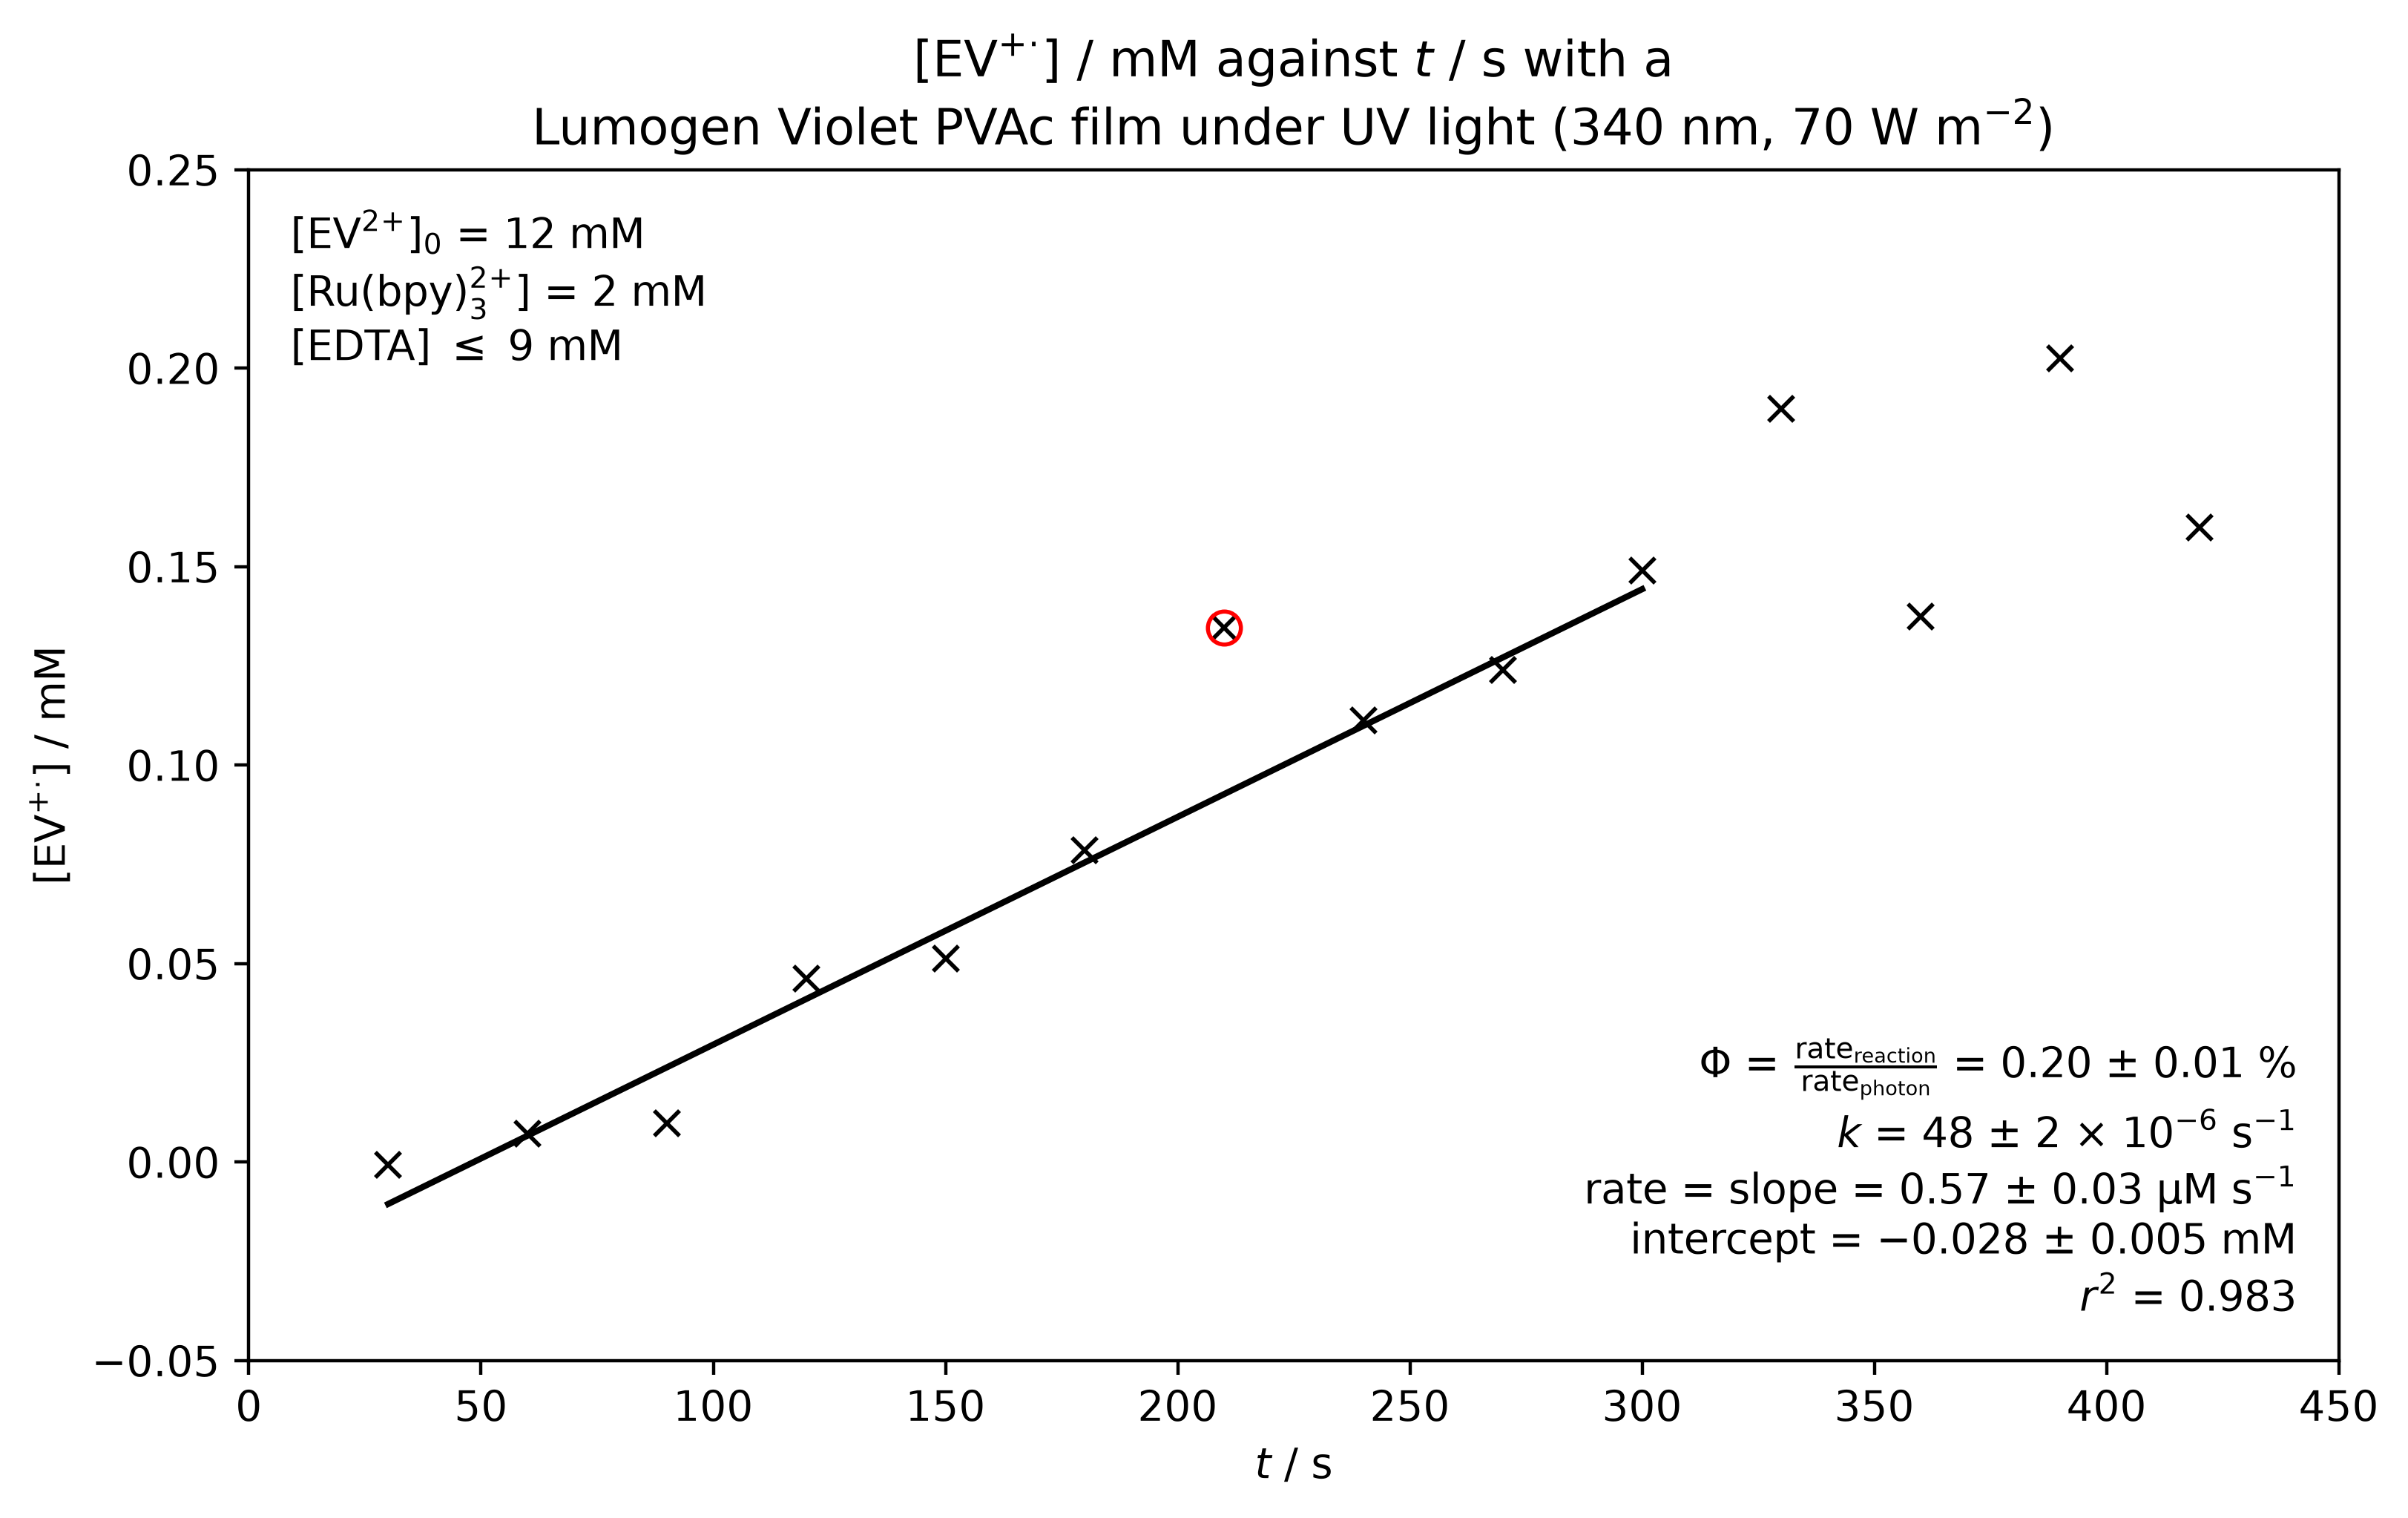

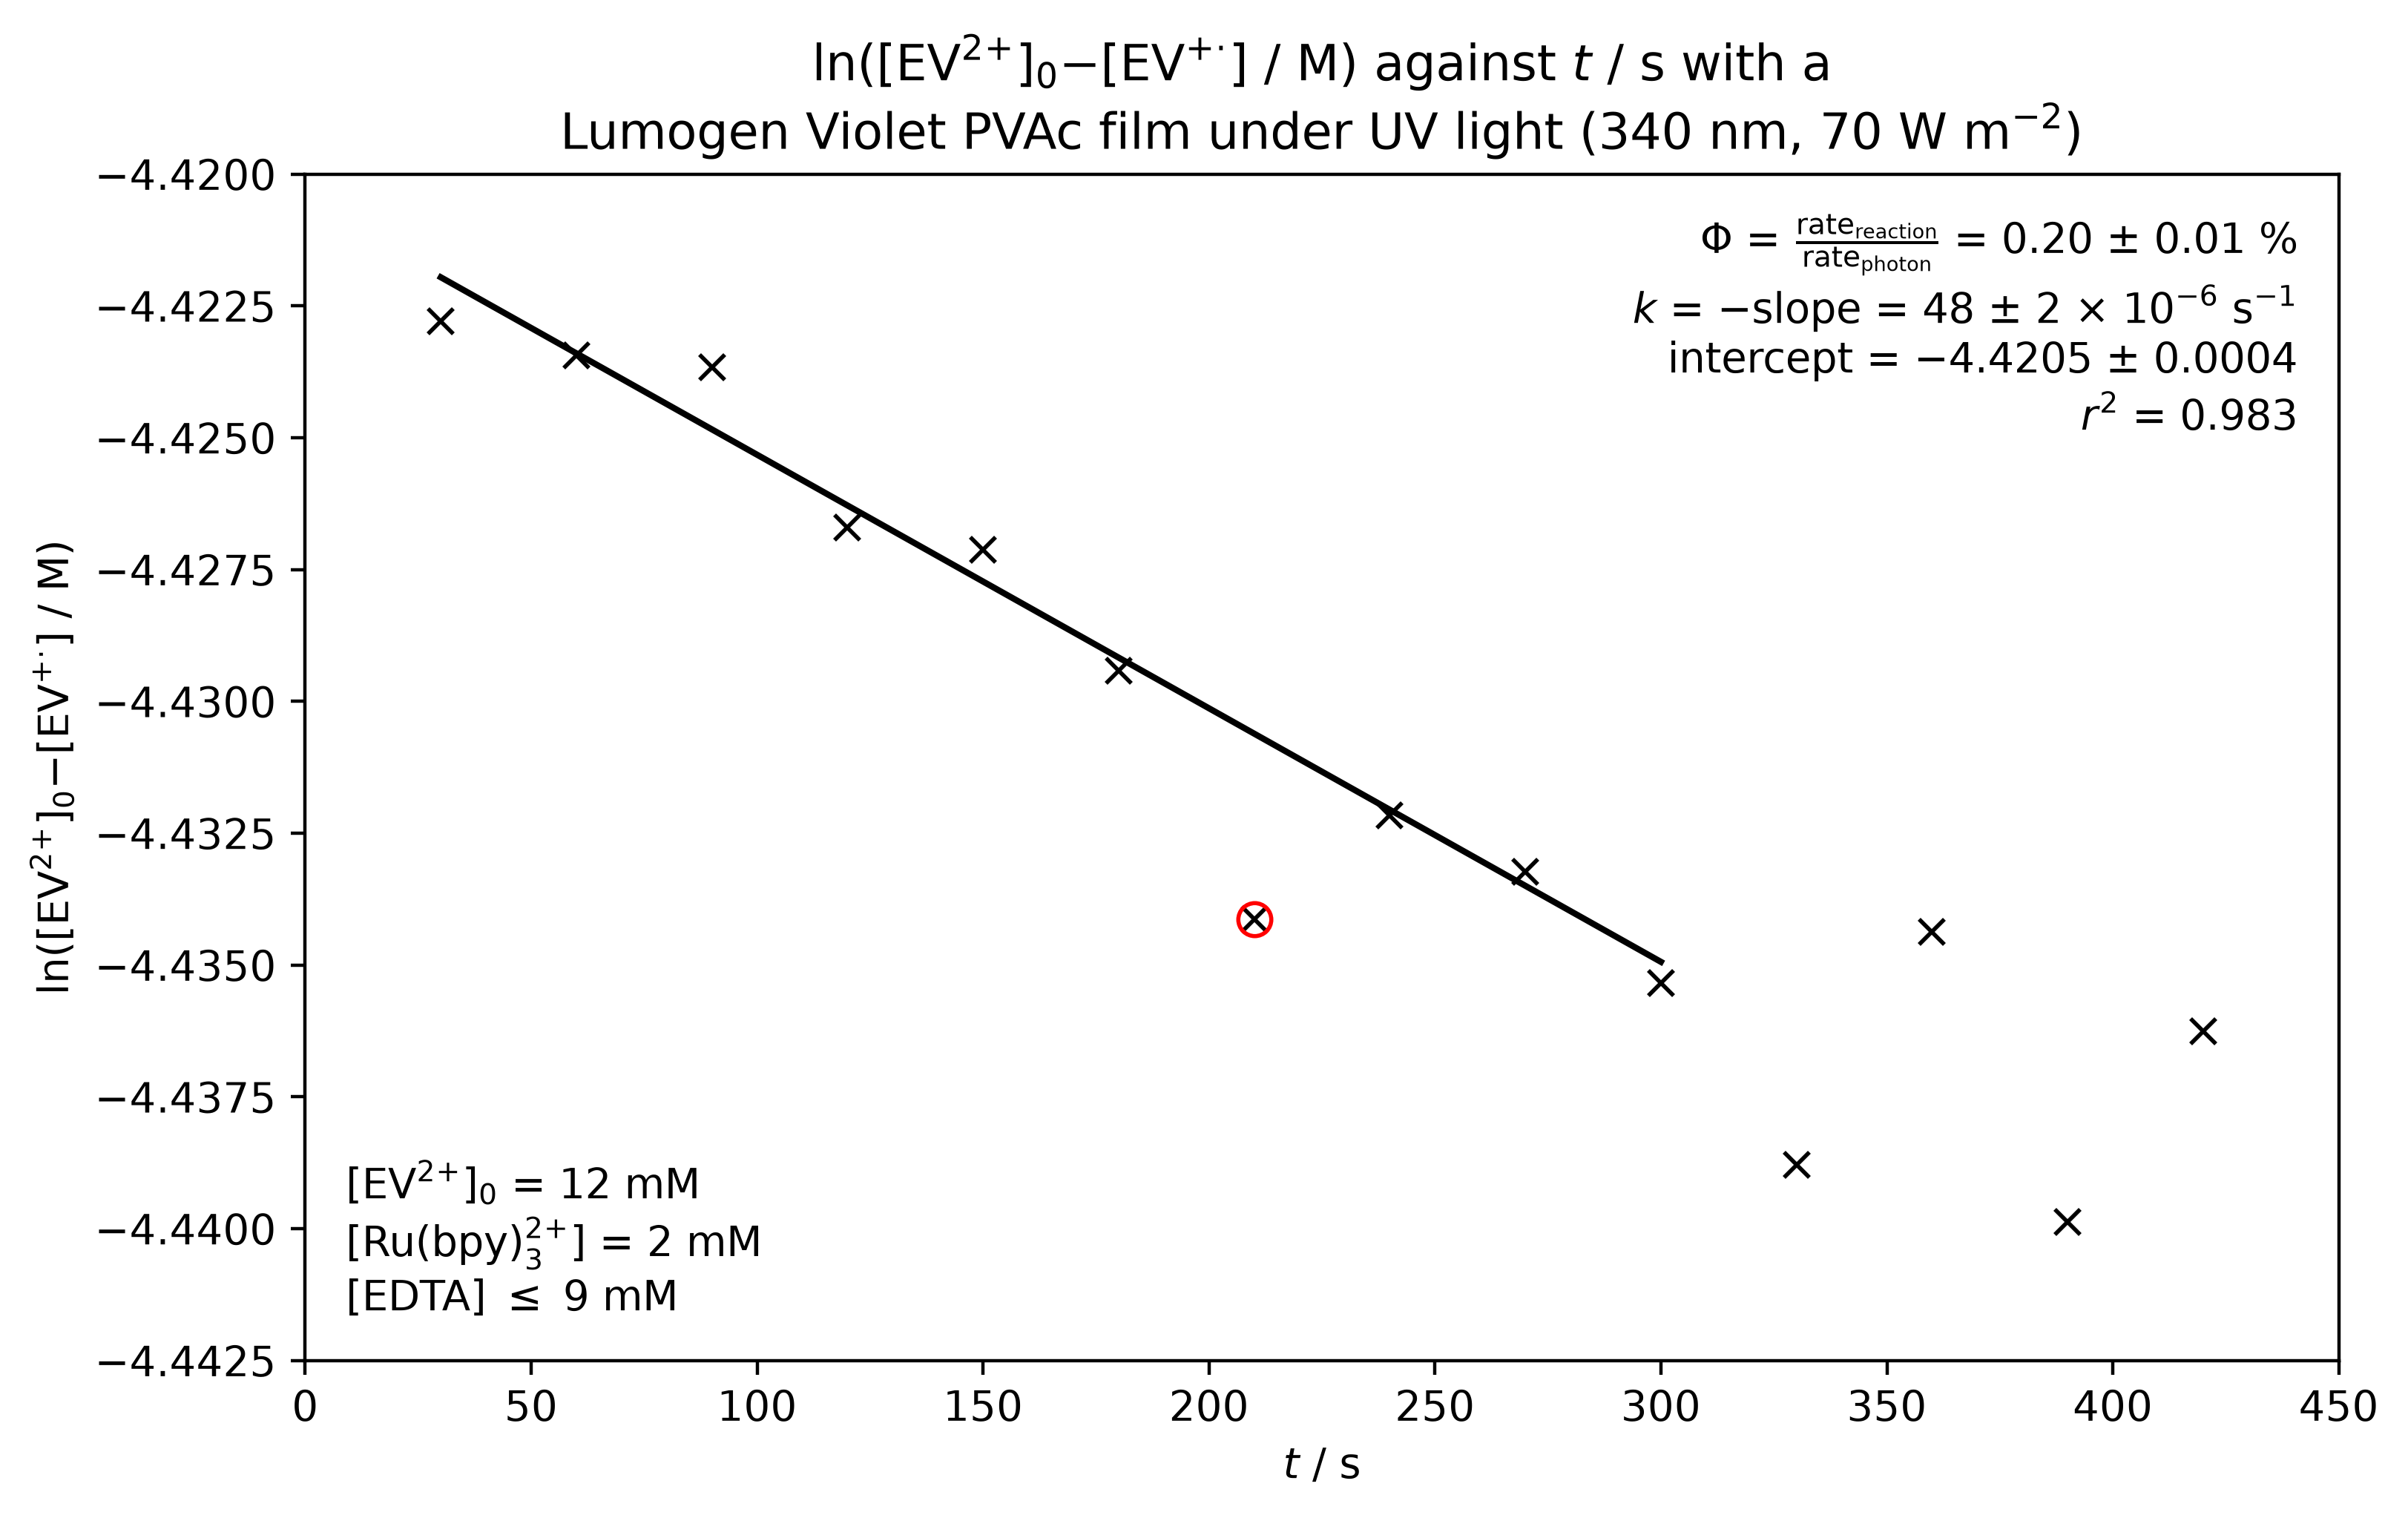

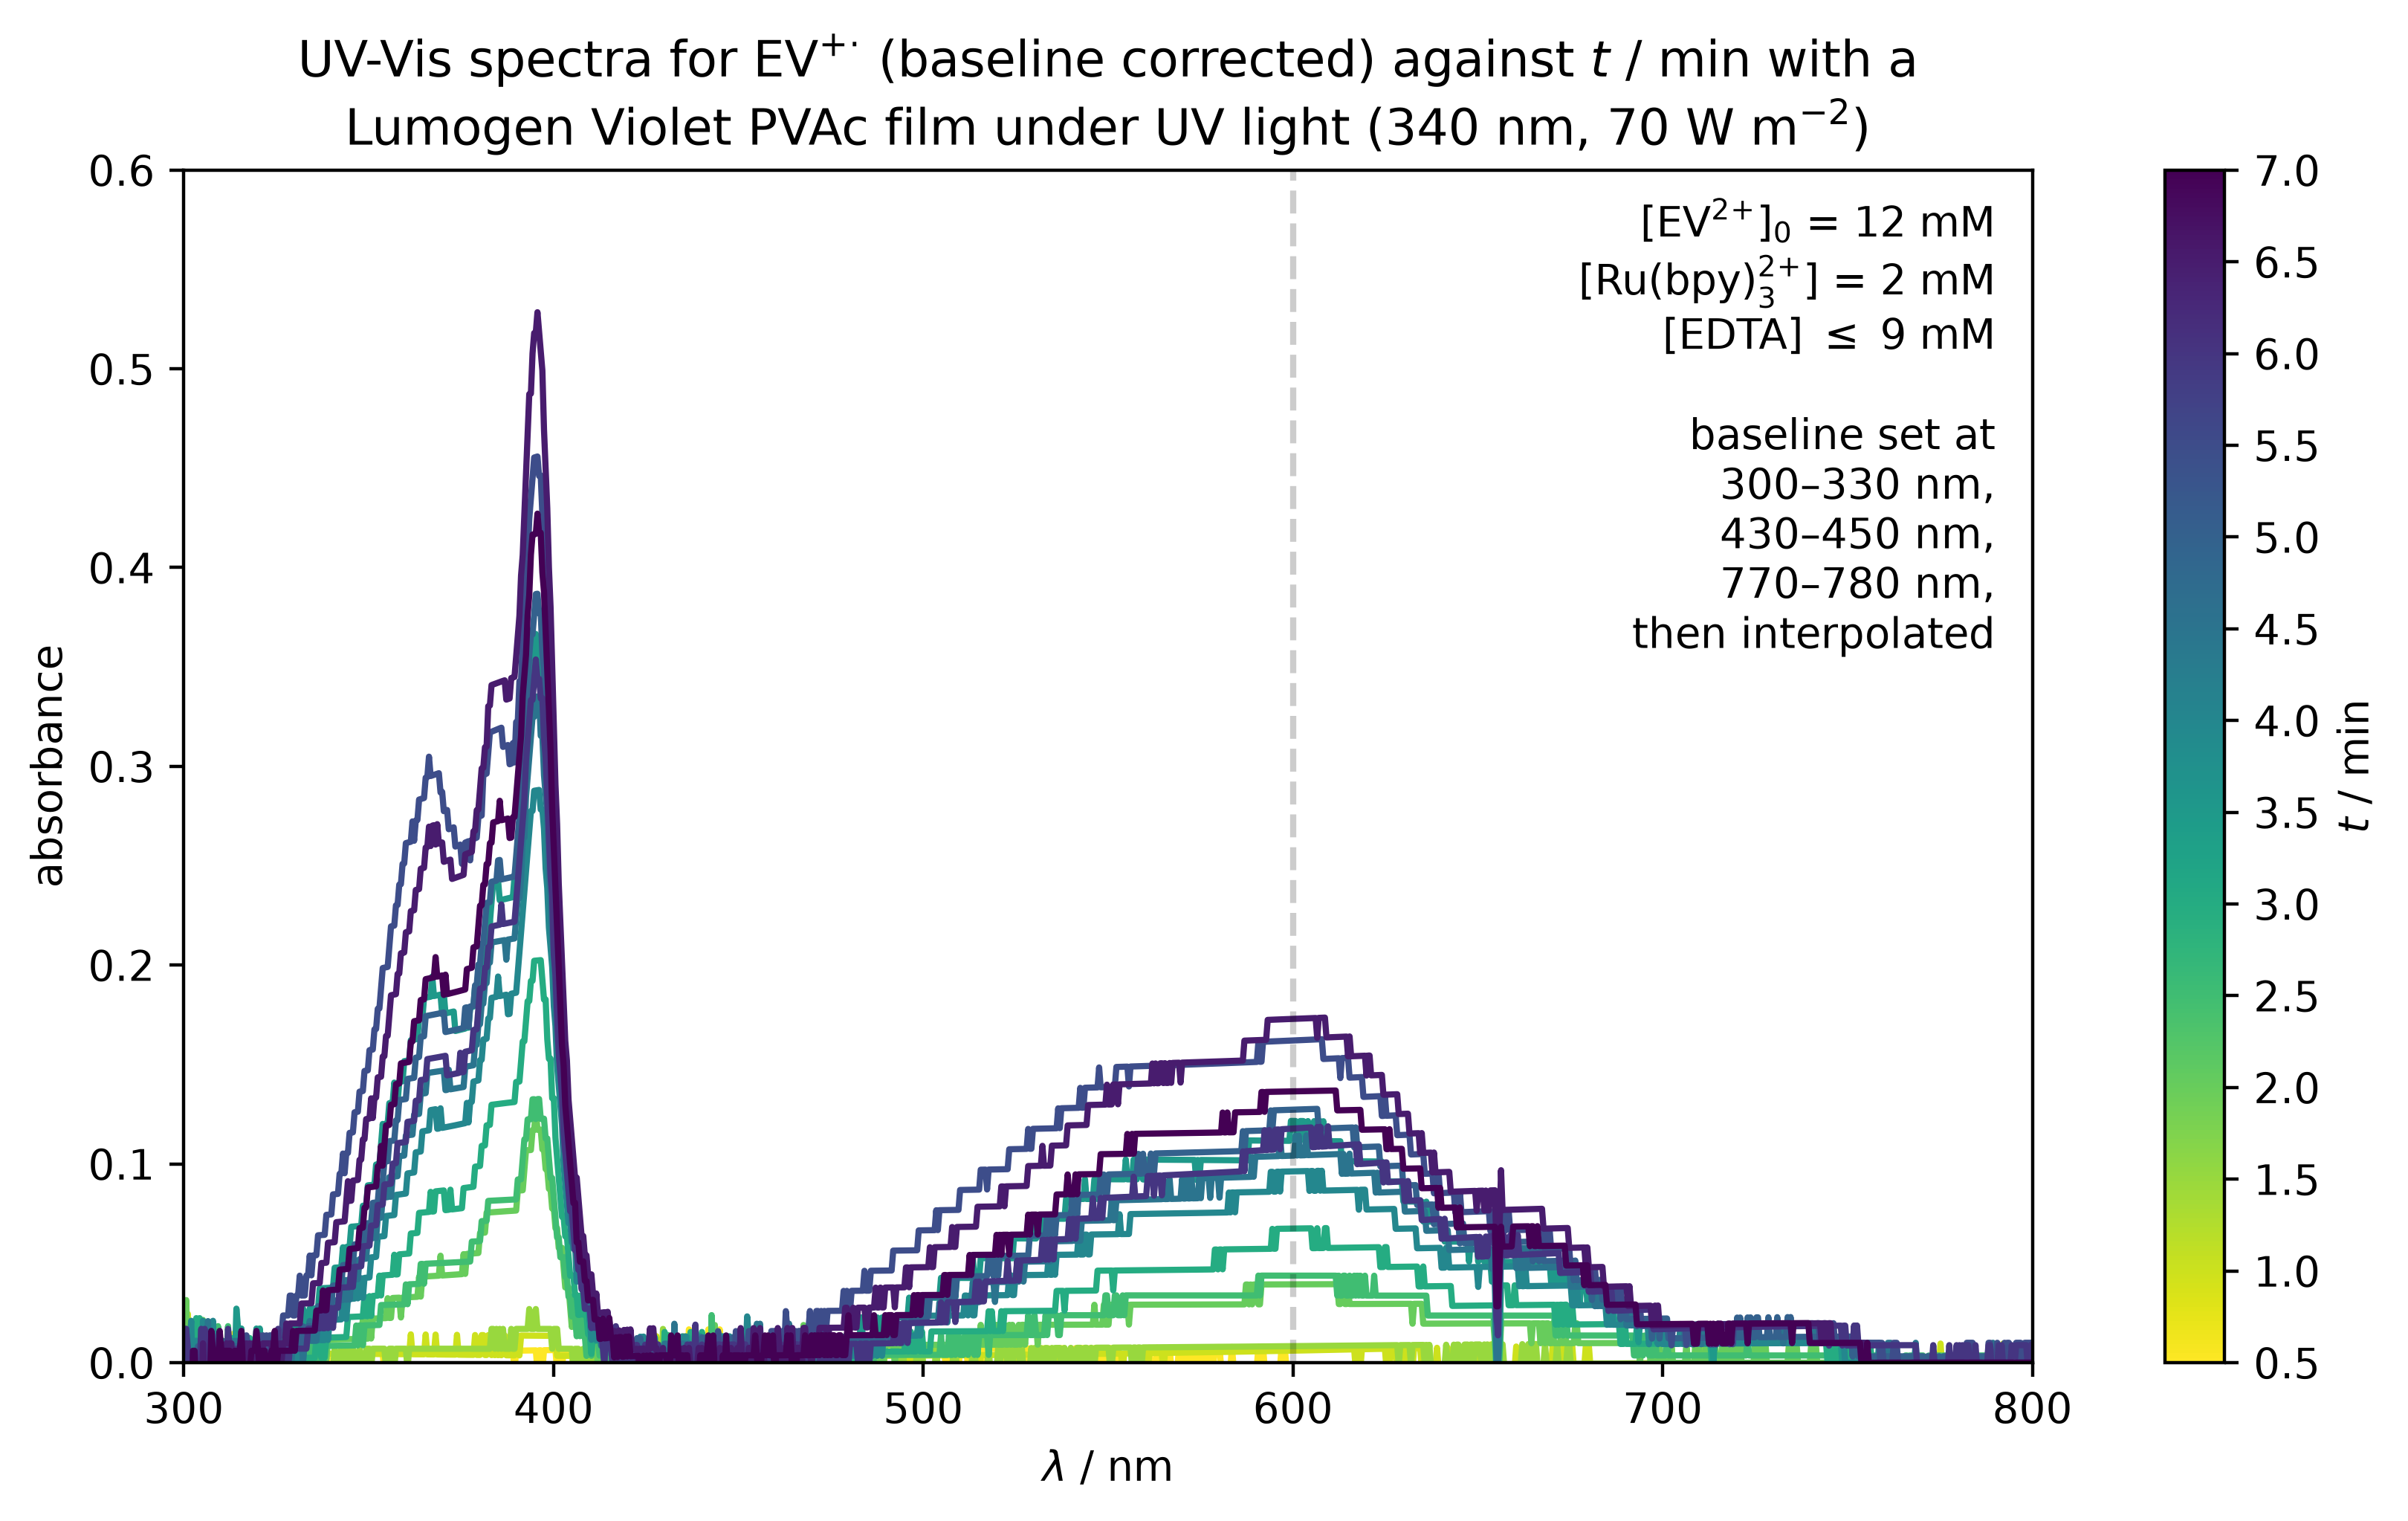

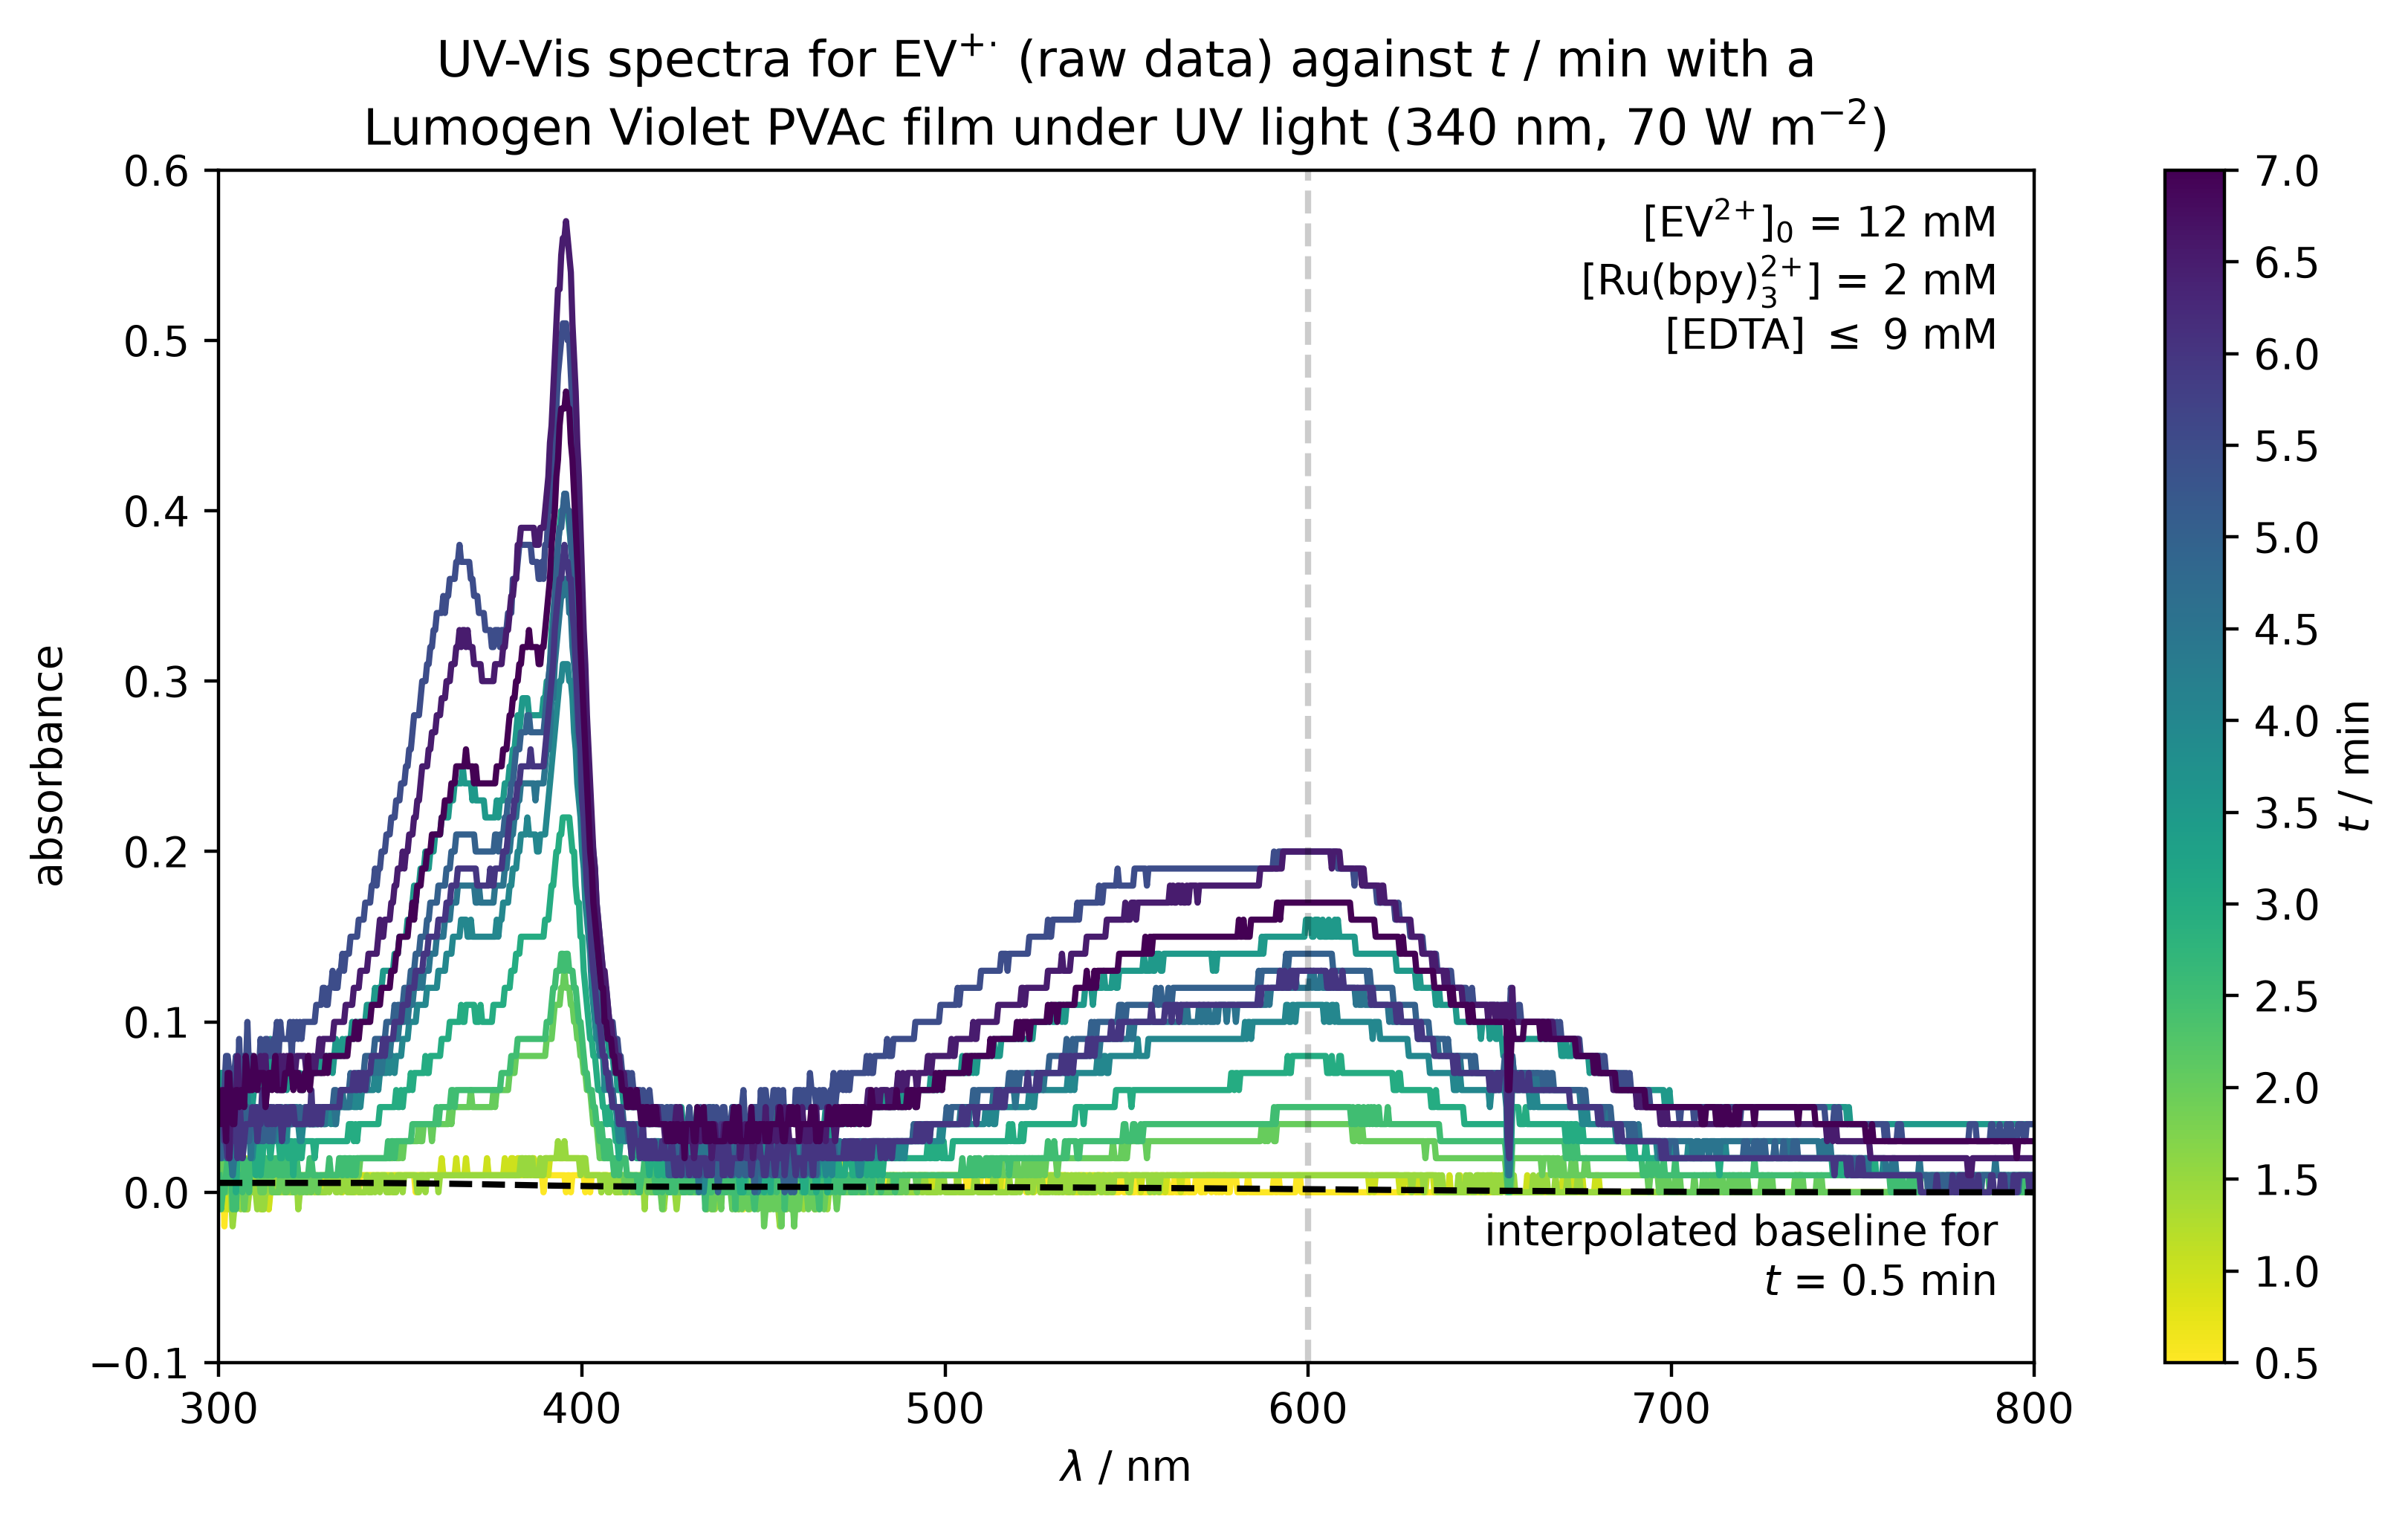

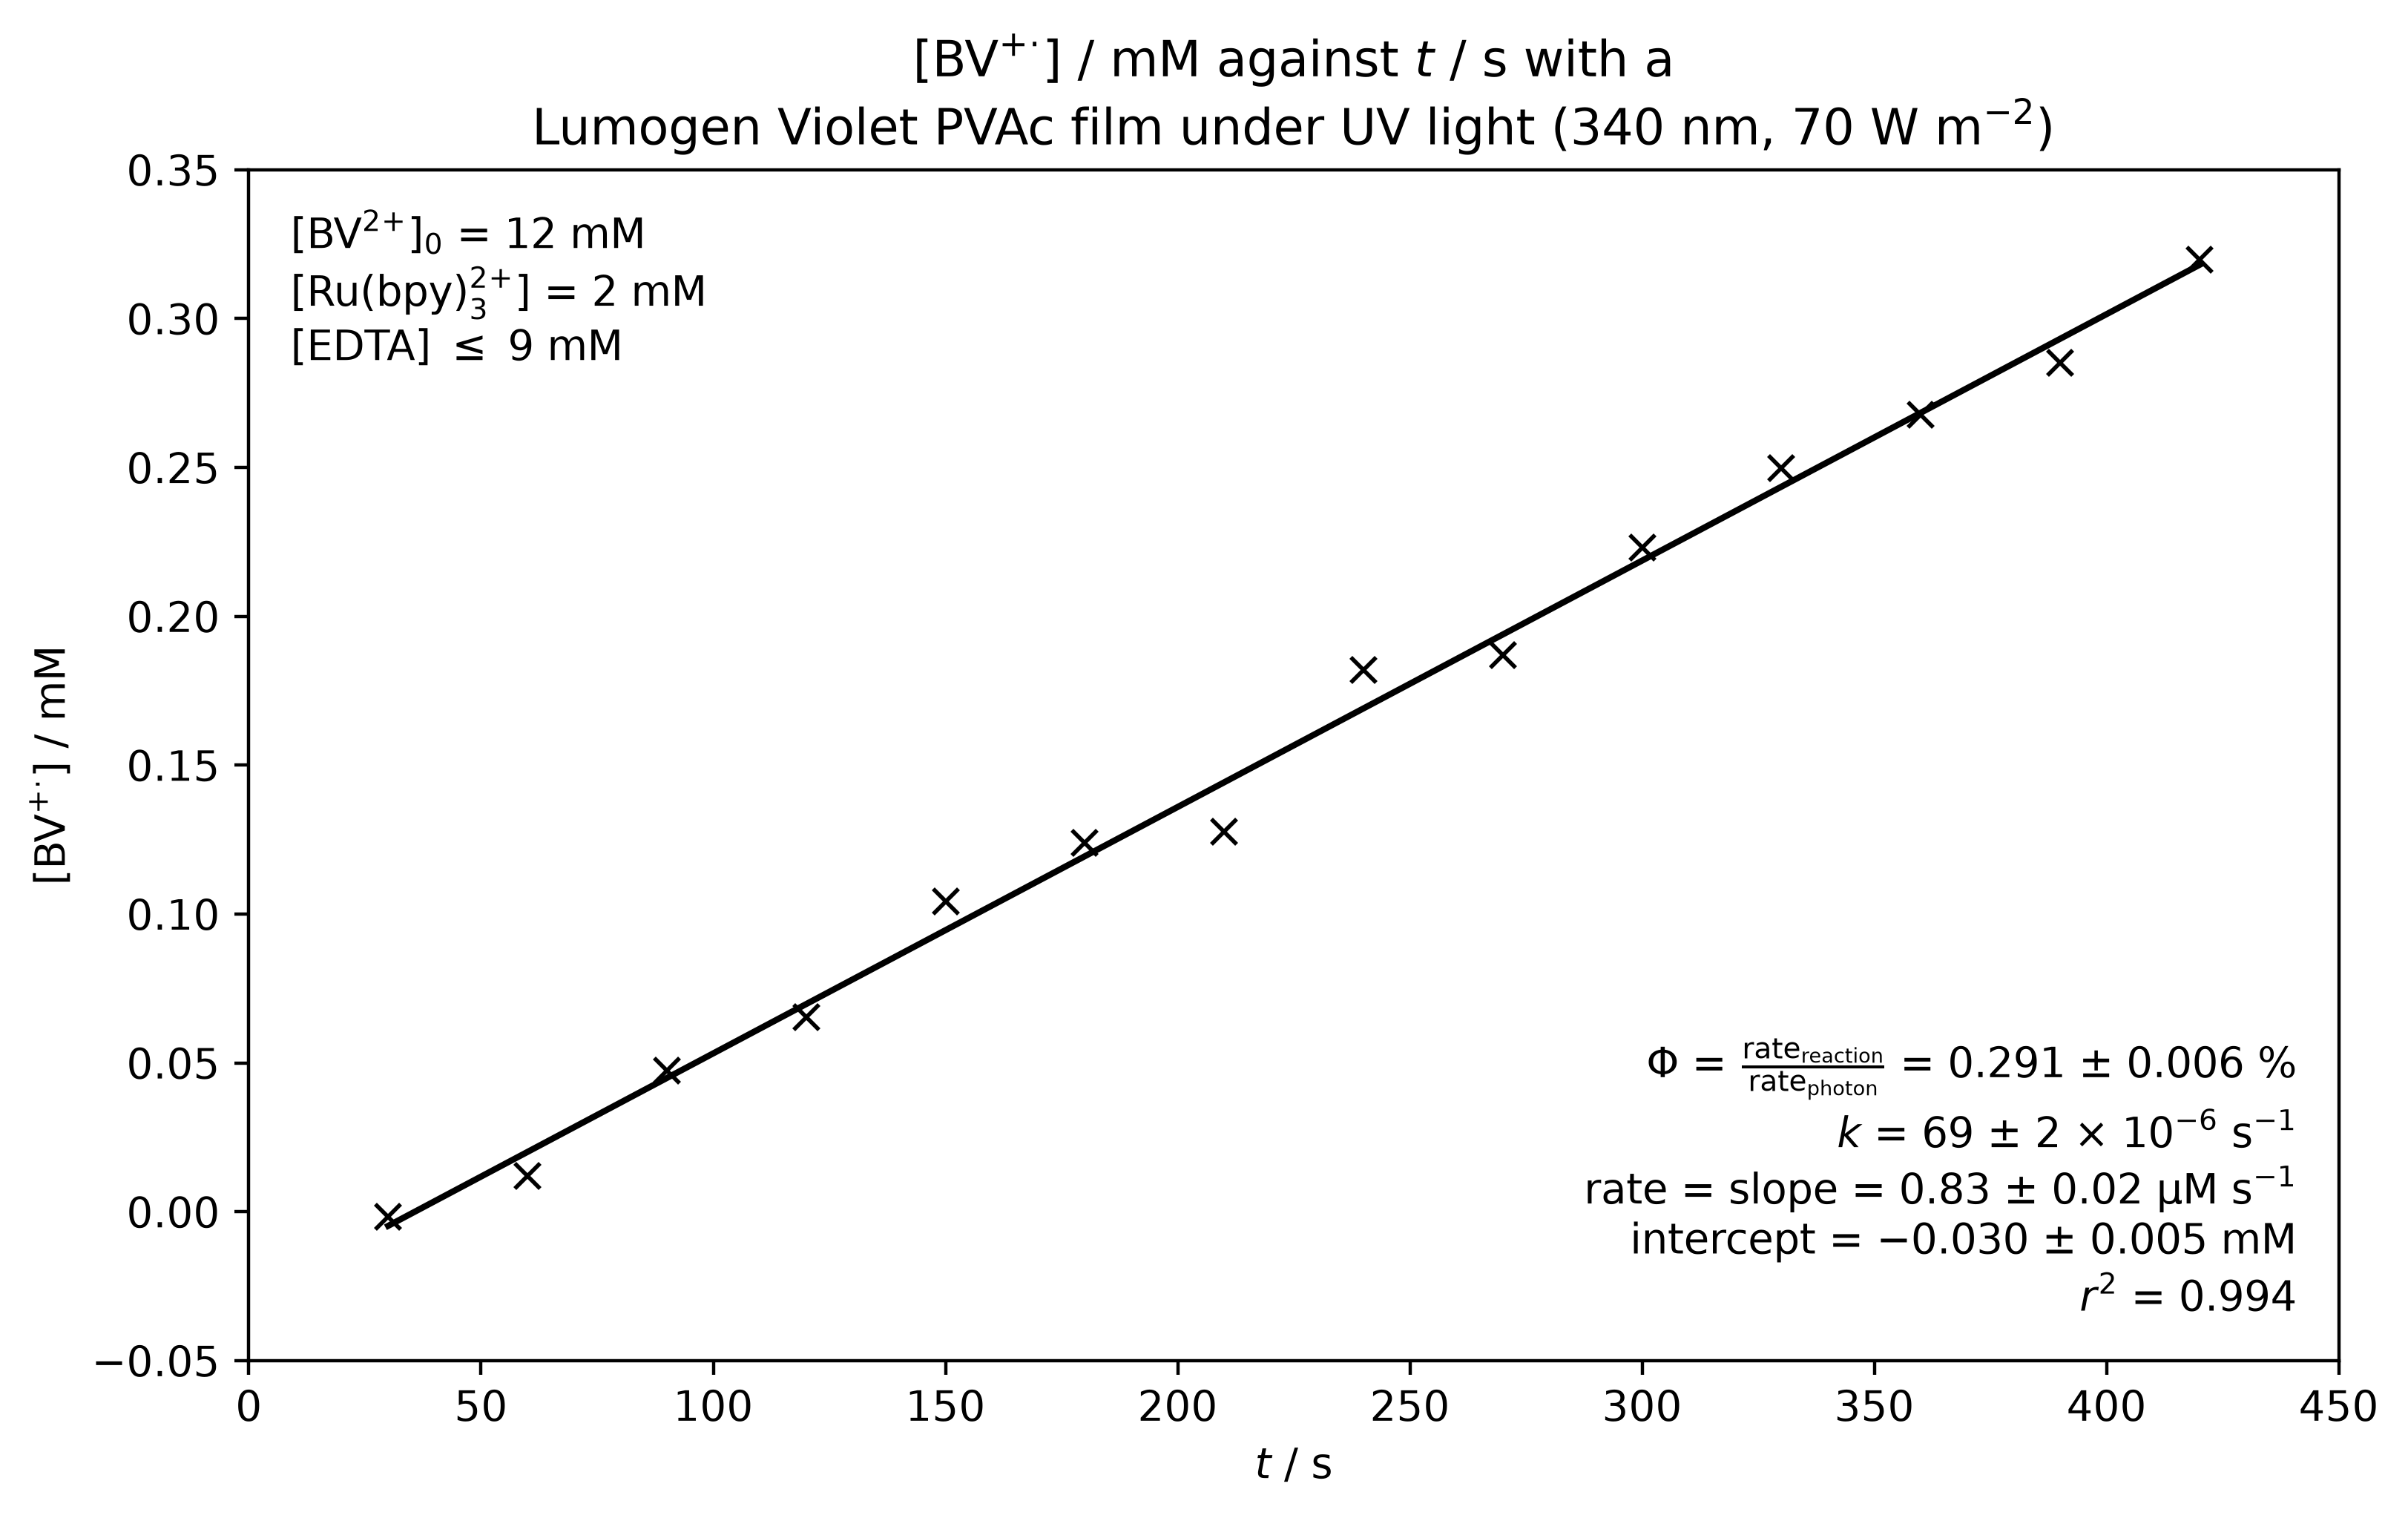

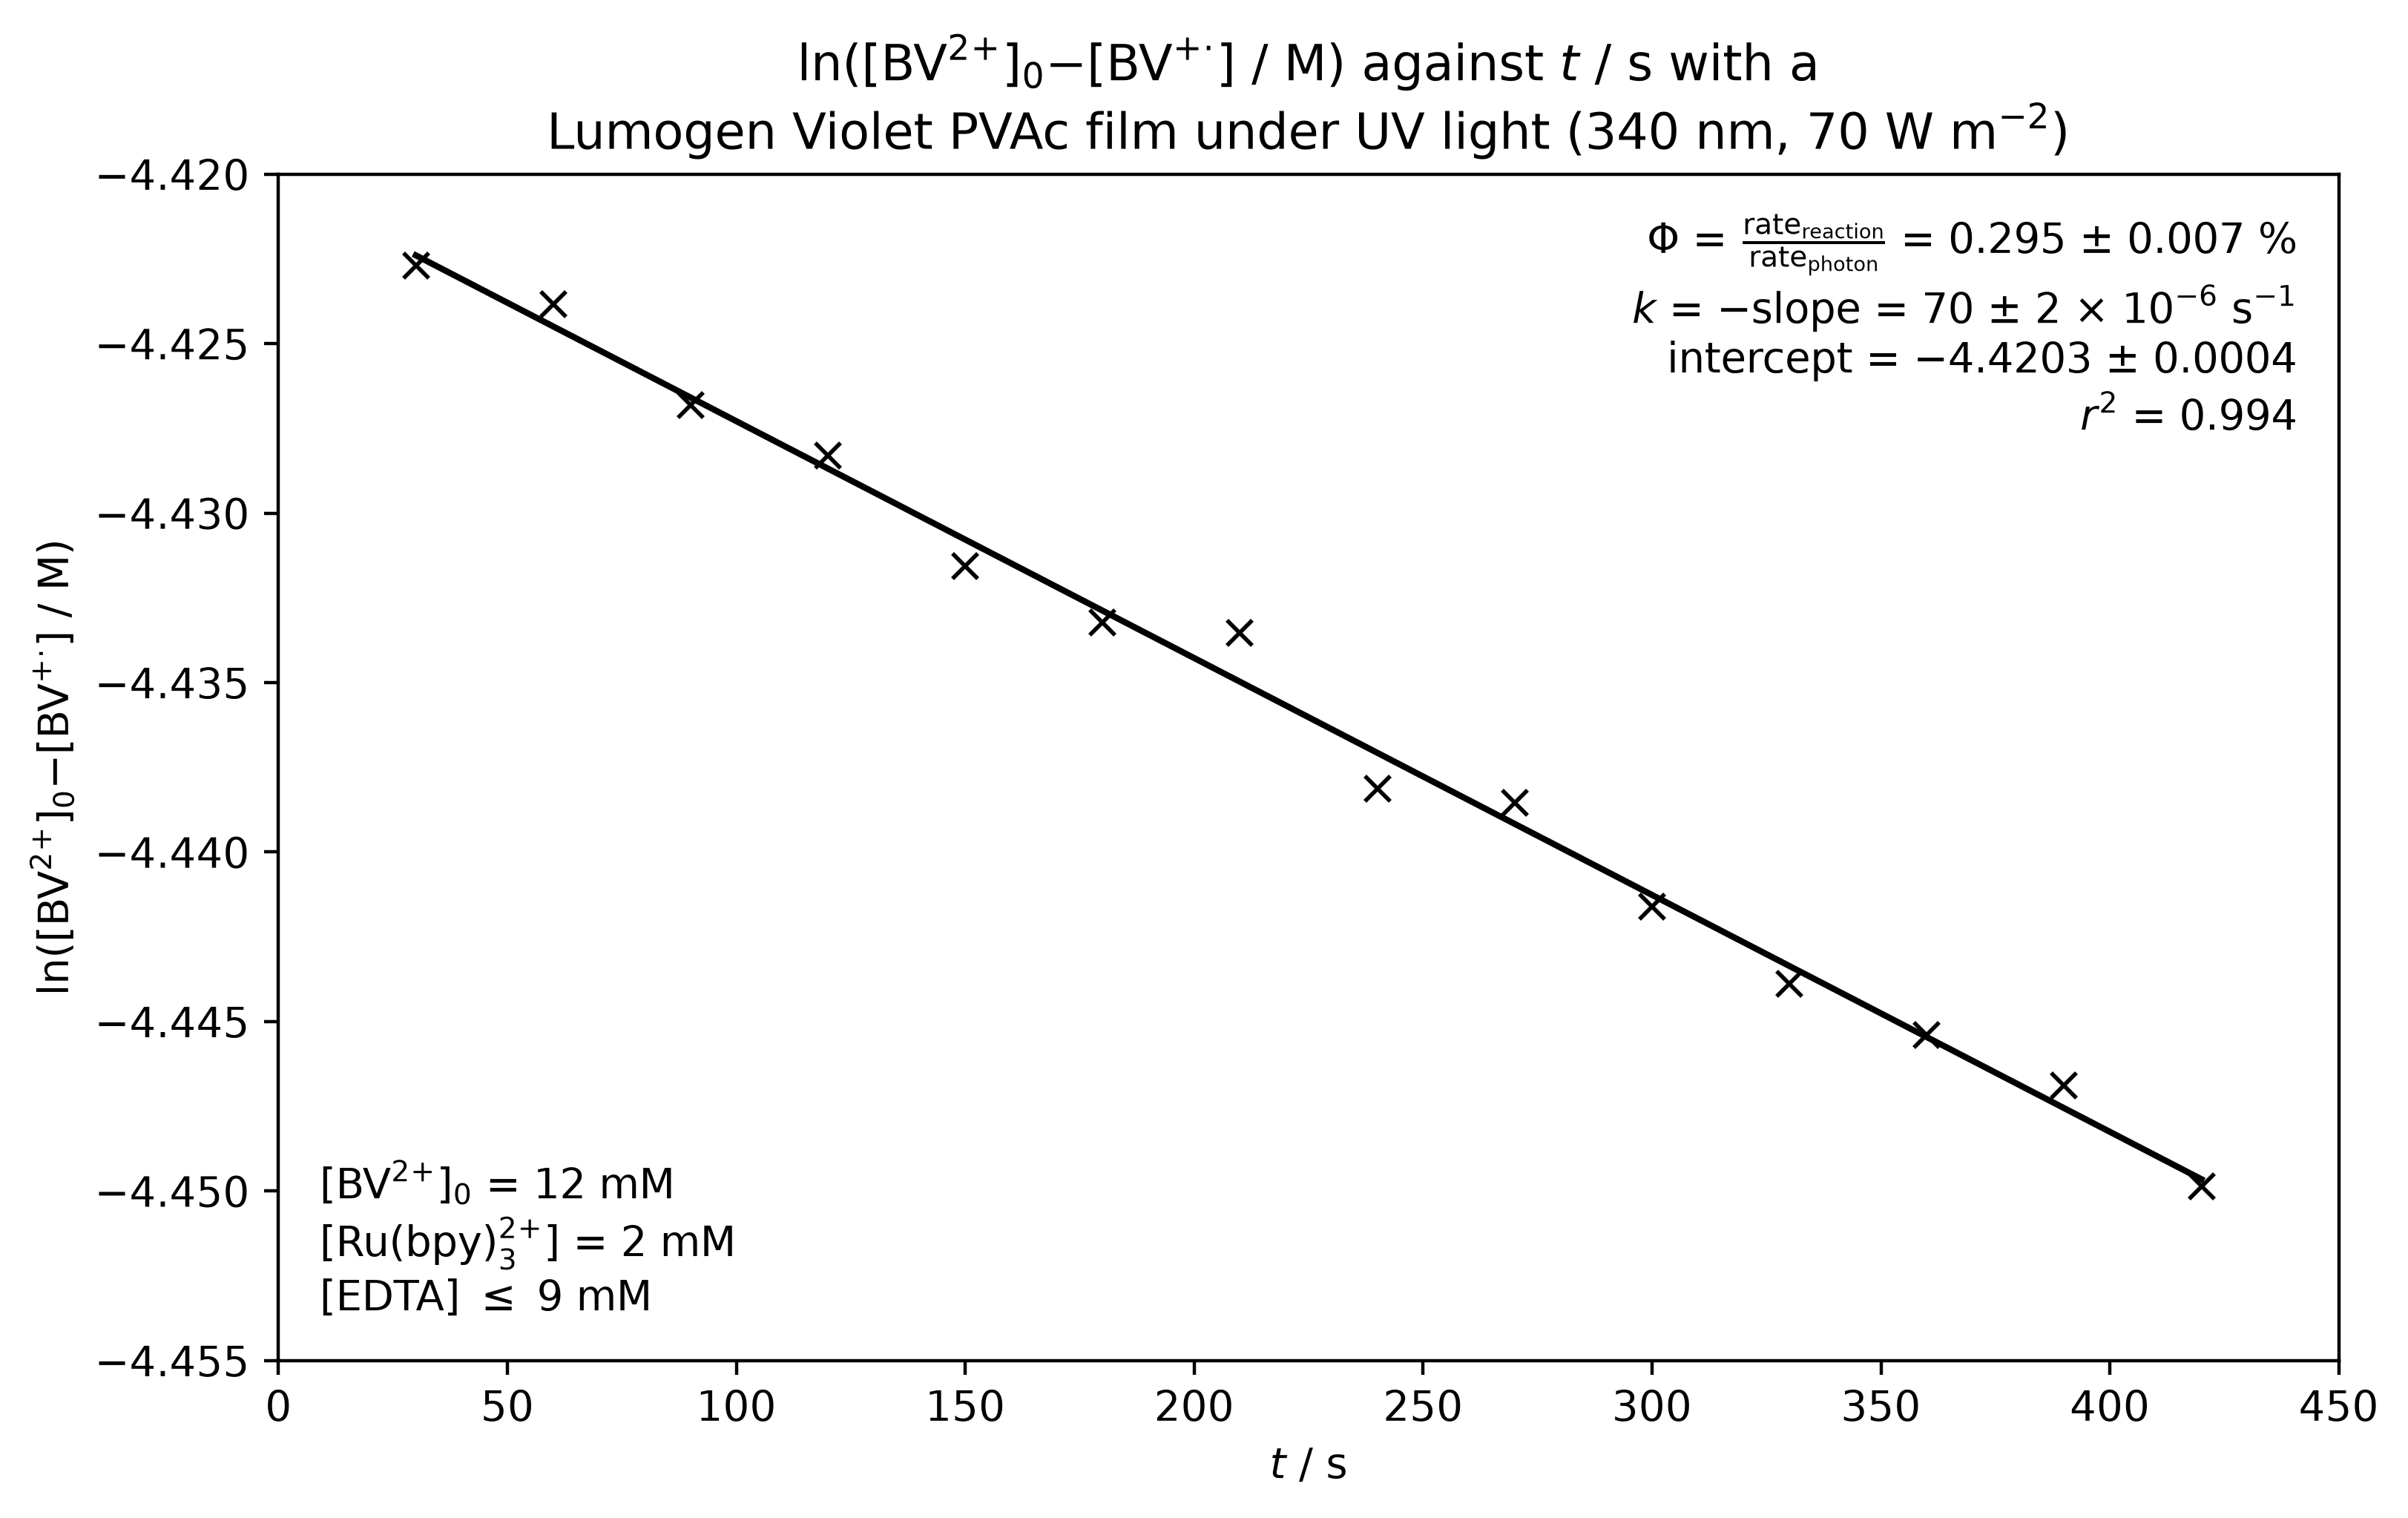

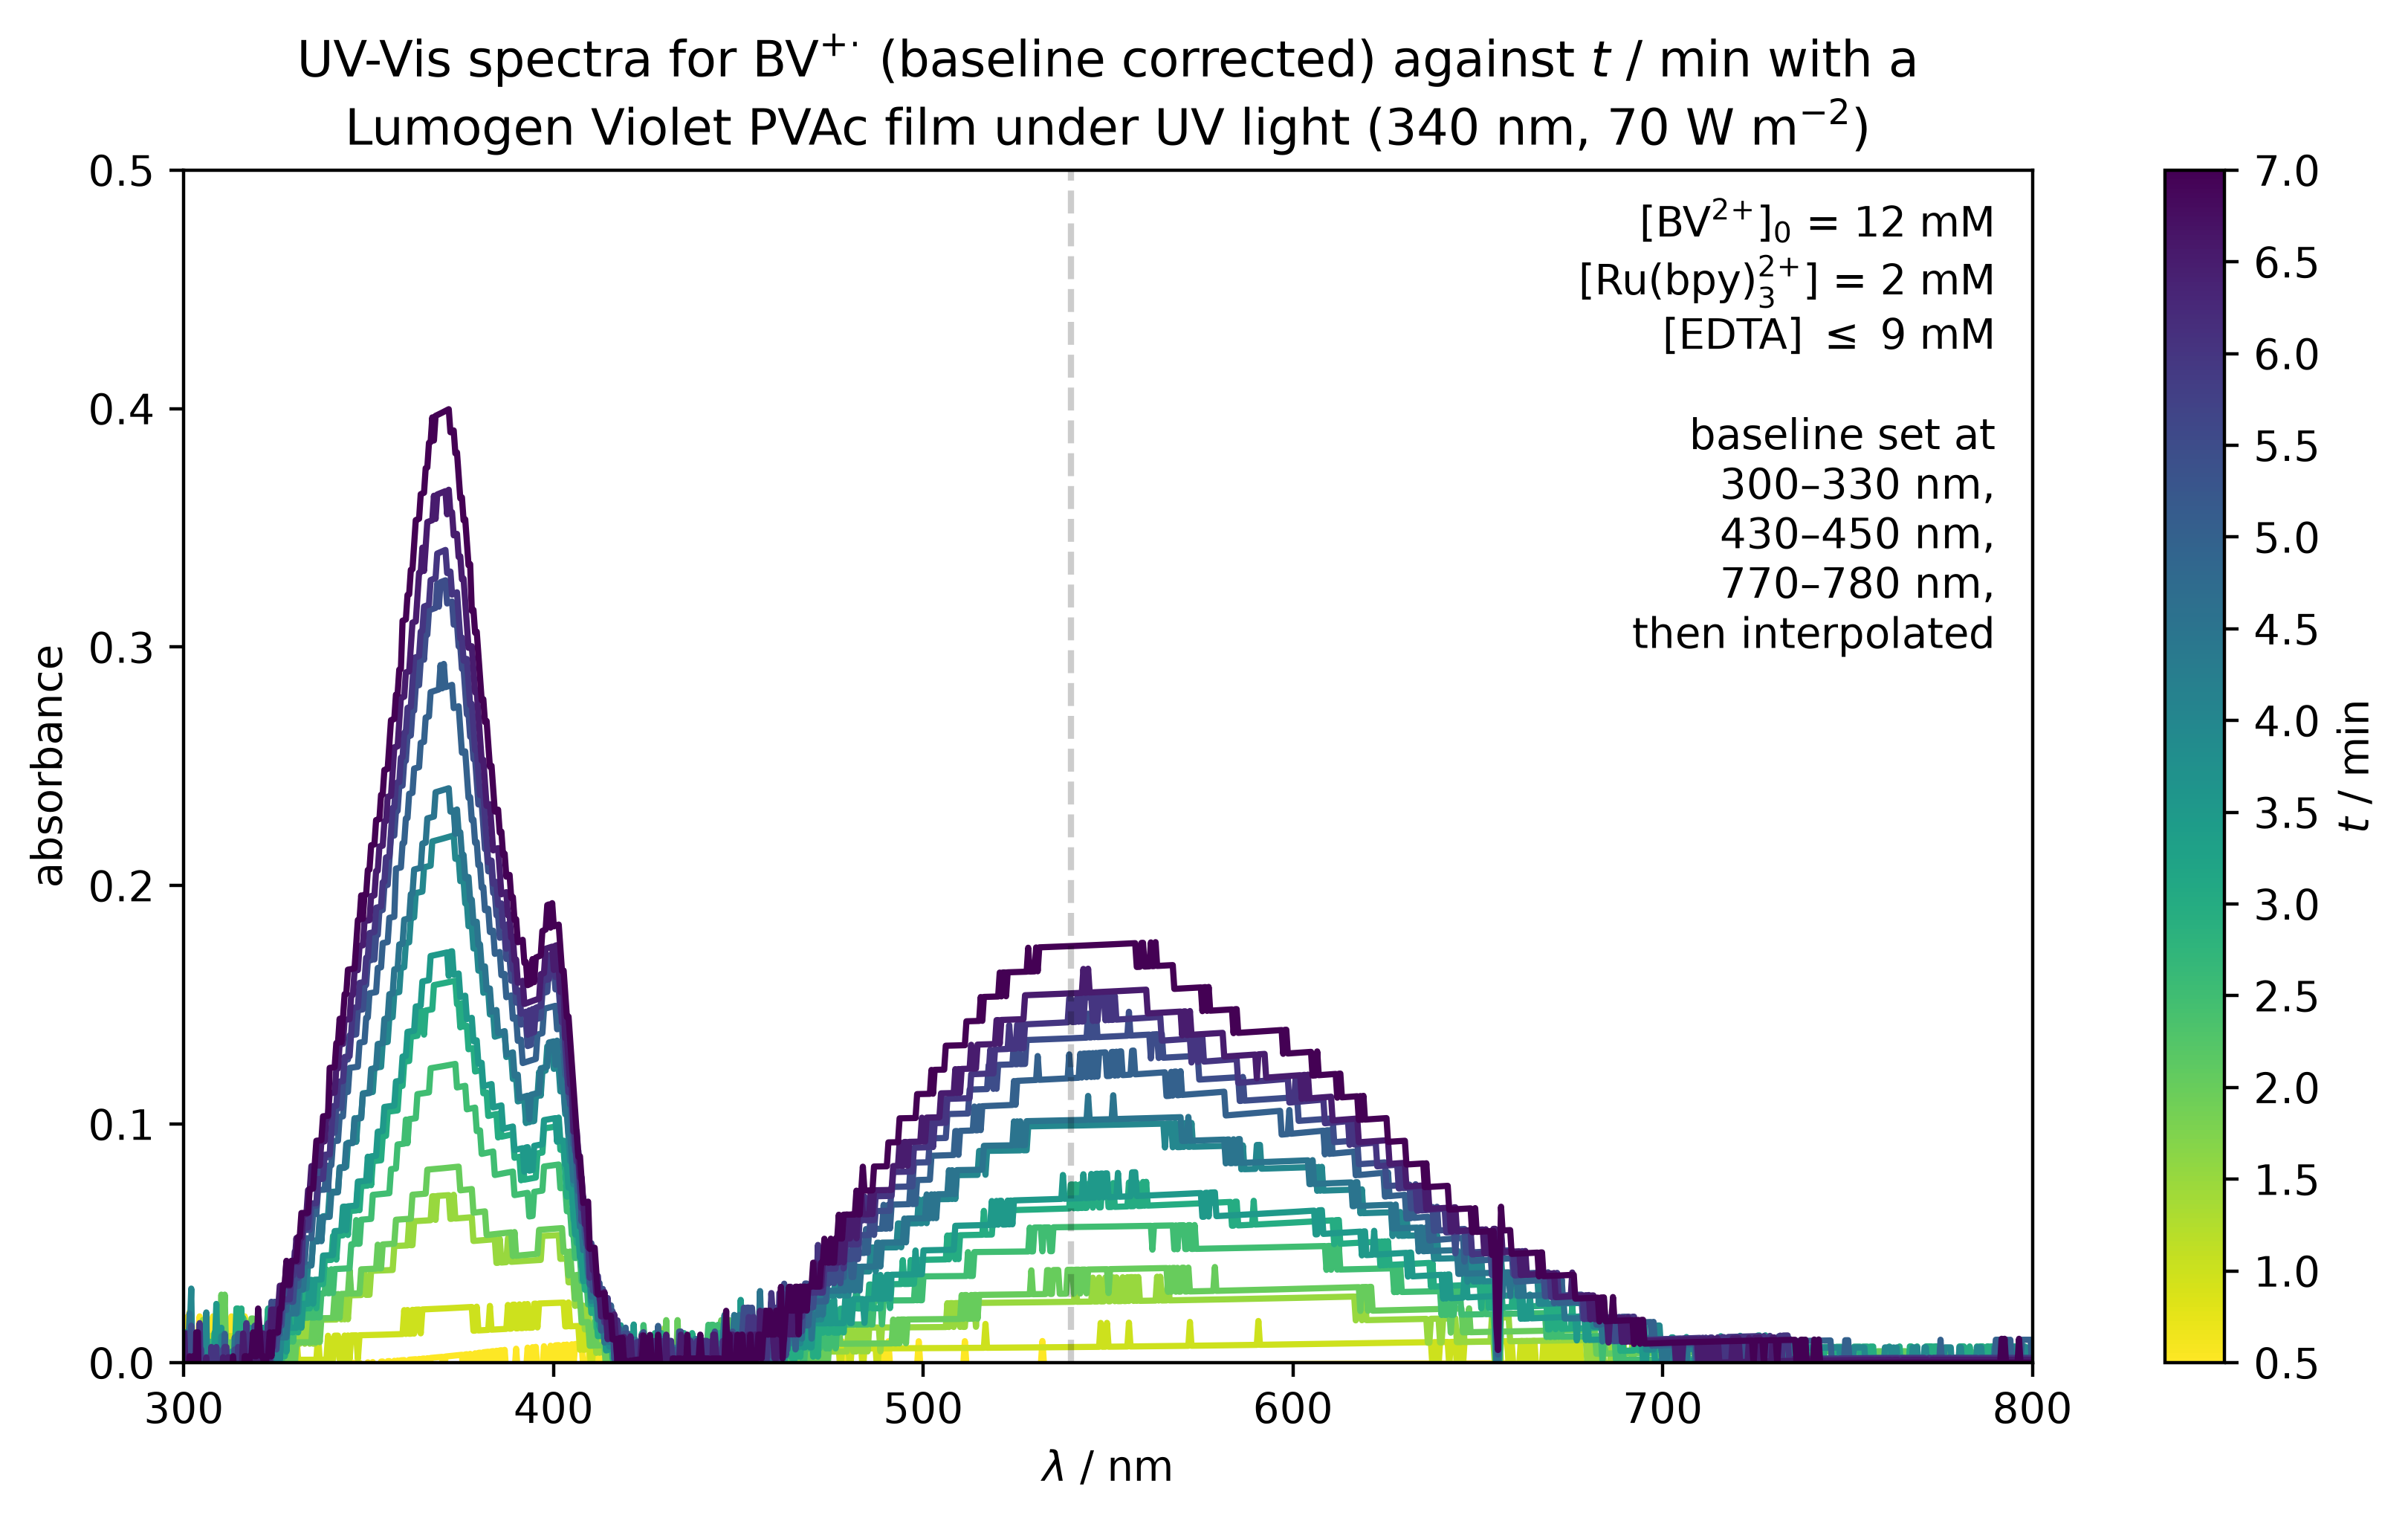

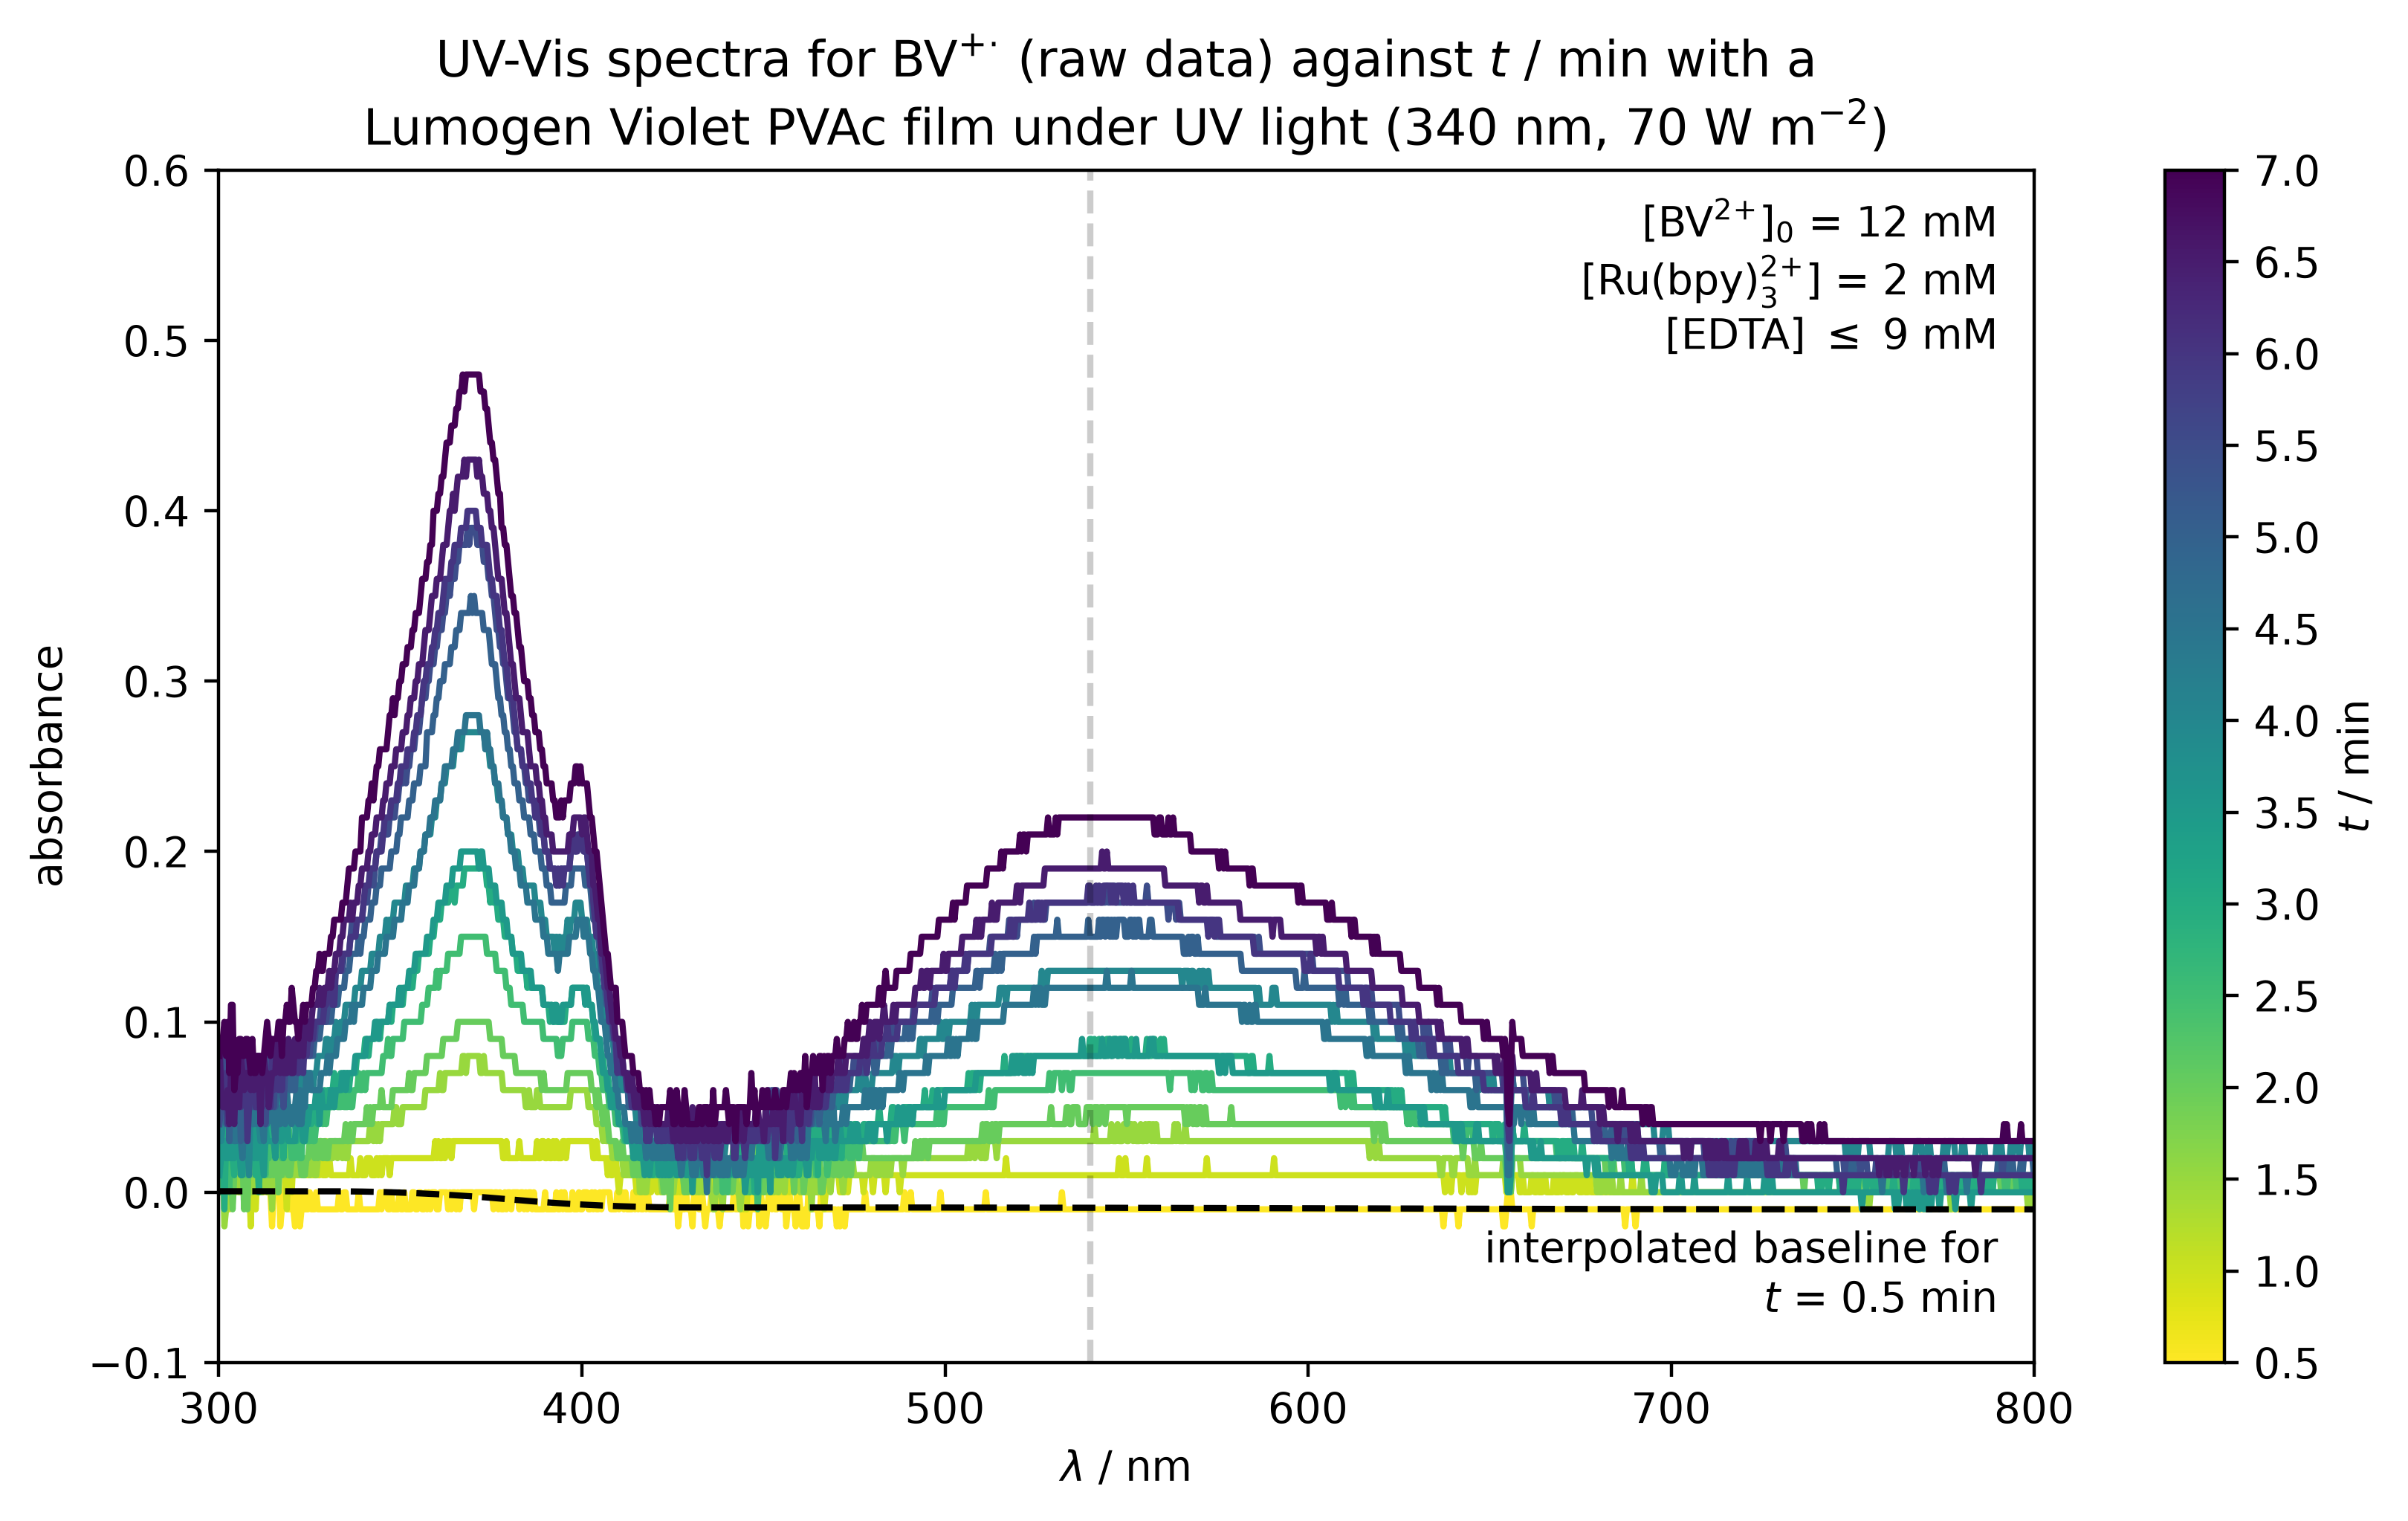

In [1]:
from lsmr_photocatalysis import StoppedFlow, X
import numpy as np

"""
Stopped-flow with reaction/LED/film in 50 ul reactor chamber.
UV 340 nm irradiation at 4.96 mW for each reaction time, then reactor chamber immediately moved to UV-Vis.
Flushed with fresh starting reaction mixture and repeated for new reaction time.

V([Ru(bpy)3]2+, 12.5 mM, pH 6 buffer) = 320 ul (2 mM),
V(XV2+, 25 mM, pH 6 buffer) = 960 ul (12 mM),
V(EDTA, saturated <25 mM, pH 6 buffer) = 720 ul (<9 mM).
"""

t = np.arange(30, 7*60+1, 30) # reaction times in s for 30 s to 7 min in 30 s intervals
c0 = 12e-3 # initial XV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 9 mM' # concentrations of other reagents
film = 'Lumogen Violet PVAc'
light = 'UV'
wavelength = 340e-9 # m
power = 4.96e-3 # W

for x, iend, exclude in [('EVrubpystopflow', 9, [6]), ('BVrubpystopflow', None, [])]: # excluded point i=6 for EV as outlier
    data = f'260713_Rubpy_{x[0]}V_EDTA_LV_UV_StopFlow'
    expt = StoppedFlow(data, t, c0, details, x, film, light, wavelength, power, correction=True)
    expt.concvstimeplot(iend=iend, exclude=exclude)
    expt.concvstimeplot(ln=True, iend=iend, exclude=exclude)
    expt.spectrumvstimeplot()